In [1]:
# yolo
# 1. 경로설정
# 2. 클래스 정립
# 3. 데이터 정리(7x7 [tx, ty, tw, th, obj] + onehot(20))
# 위까지가 정리
# 4. 데이터 로드
# 5. 모델 설계(백본모델 사용)
# 6. loss 정립()
# 7. 학습
# 8. 예측(사이에 후처리도 있어야 함)

In [1]:
# 0. 작업 준비
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, utils, datasets, transforms
import xml.etree.ElementTree as ET
from tqdm import tqdm

In [2]:
# 1. 경로설정
basepath = 'data/VOCdevkit/VOC2012'
IMG_DIR = os.path.join(basepath, 'JPEGImages')
ANN_DIR = os.path.join(basepath, 'Annotations')
SET_DIR = os.path.join(basepath, 'ImageSets','Main')
TRAIN_LIST = os.path.join(SET_DIR, 'train.txt')
VAL_LIST = os.path.join(SET_DIR, 'val.txt')

# 2. 클래스 정립
VOC_CLASSES = ['aeroplane', 'bicycle', 'bird', 'boat',
'bottle', 'bus', 'car', 'cat', 'chair',
'cow', 'diningtable', 'dog', 'horse',
'motorbike', 'person', 'pottedplant',
'sheep', 'sofa', 'train', 'tvmonitor']
C = len(VOC_CLASSES)
S = 7 # 그리드 사이즈. YOLO는 7x7로 사용되었음
B = 2
IMG_SIZE = 224
CELL = IMG_SIZE//S

def read_split_list(list_path):
    with open(list_path, 'r') as f:
        ids = [line.strip() for line in f if line.strip()]
    return ids

def id_to_paths(img_id):
    return os.path.join(IMG_DIR, f'{img_id}.jpg'), os.path.join(ANN_DIR, f'{img_id}.xml')

# 3. 데이터 정리(7x7 [tx, ty, tw, th, obj] + onehot(20))
def _get_text(node, tag, default=None):
    el = node.find(tag)
    return el.text if el is not None else default

def build_label_from_xml(xml_path, classes):
    label = np.zeros((S,S,5+len(classes)), dtype=np.float32) # 운영체제 비트수에 맞게 가는 것이 좋은 거 같음. 모르면 float32
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    W = float(_get_text(size, 'width', 1))
    H = float(_get_text(size, 'height', 1))
    for obj in root.findall('object'):
        c_name = _get_text(obj, 'name', '').lower()
        if c_name not in classes:
            continue
        cls_idx = classes.index(c_name)
        bnd = obj.find('bndbox')
        xmin = float(_get_text(bnd, 'xmin', '1'))
        ymin = float(_get_text(bnd, 'ymin', '1'))
        xmax = float(_get_text(bnd, 'xmax', '1'))
        ymax = float(_get_text(bnd, 'ymax', '1'))

        sx = IMG_SIZE/W
        sy = IMG_SIZE/H
        xmin *= sx
        ymin *= sy
        xmax *= sx
        ymax *= sy

        cx = (xmin+xmax)/2.0
        cy = (ymin+ymax)/2.0
        w = (xmax+xmin)
        h = (ymax+ymin)

        gx = int(cx // CELL)
        gy = int(cy // CELL)
        if not (0 <= gx < S and 0 <= gy < S):
            continue
        tx = (cx - gx * C)/CELL
        ty = (cy - gy * C)/CELL
        tw = w/IMG_SIZE
        th = h/IMG_SIZE

        label[gy, gx, 0:5] = np.array([tx, ty, tw, th, 1.0], dtype=np.float32)
        label[gy, gx, 5+cls_idx] = 1.0

    return label

# 위까지가 정리
# 4. 데이터 로드
class VOCDatasetYOLOv1(Dataset):
    def __init__(self, id_list_path, classes):
        self.ids = read_split_list(id_list_path)
        self.classes = classes
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, index):
        img_id = self.ids[index]
        img_p, ann_p = id_to_paths(img_id)
        img = cv2.imread(img_p)
        if img is None:
            raise RuntimeError('파일이 없습니다.')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype(np.float32)/255.0
        img = np.transpose(img, (2,0,1)) # torch에서 사용하도록 채널 변경

        label = build_label_from_xml(ann_p, self.classes)
        return torch.from_numpy(img), torch.from_numpy(label)
    
tr_ds = VOCDatasetYOLOv1(TRAIN_LIST, VOC_CLASSES)
val_ds = VOCDatasetYOLOv1(VAL_LIST, VOC_CLASSES)

BATCH_SIZE = 32
tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# 5. 모델 설계(백본모델 사용..여기선 vgg16)
class YOLOV1VGG16(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.S = S
        self.B = B
        self.C = n_classes

        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.backbone = vgg.features

        for p in self.backbone.parameters():
            p.requires_grad = False # 동결
        self.head = nn.Sequential(
            nn.Conv2d(512, 1024, 3,1,1),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(1024, 1024, 3,1,1),
            nn.LeakyReLU(0.01, inplace=True),
            nn.MaxPool2d(2,2),
            nn.Conv2d(1024, 1024, 3,1,1),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(1024, 1024, 3,1,1),
            nn.LeakyReLU(0.01, inplace=True),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*3*1024, 4096),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, self.S * self.S * (10+self.C)), # 7*7*10+클래스개수(20)
        )
    
    def forward(self, x):
        x = self.backbone(x) # N,512,7,7
        x = self.head(x) # N,1024,3,3
        x = self.fc(x) # N,S,S
        x = x.view(-1, self.S,self.S, 10+self.C) # N,S,S,10+C
        return x
    
# 6. loss 정립()
def _boxes_cell_to_abs(boxes, S, device):
    N = boxes.shape[0]
    yy, xx  = torch.meshgrid(torch.arange(S, device=device), torch.arange(S, device=device), indexing='ij')
    yy = yy.view(1,S,S,1).float()
    xx = xx.view(1,S,S,1).float()

    cx = (boxes[...,0:1]+xx)/S
    cy = (boxes[...,1:2]+yy)/S
    w = boxes[...,2:3]
    h = boxes[...,3:4]
    return torch.cat([cx,cy,w,h], dim=1)

def bbox_iou_xyhw(b1,b2, eps=1e-7):
    cx1, cy1, w1, h1 = b1.unbind(-1) 
    cx2, cy2, w2, h2 = b2.unbind(-1) 

    x1_min = cx1-0.5*w1
    x1_max = cx1+0.5*w1
    y1_min = cy1-0.5*h1
    y1_max = cy1+0.5*h1

    x2_min = cx2-0.5*w2
    x2_max = cx2+0.5*w2
    y2_min = cy2-0.5*h2
    y2_max = cy2+0.5*h2

    # 교집합에 대한 정리
    inter_x_min = torch.maximum(x1_min, x2_min)
    inter_y_min = torch.maximum(y1_min, y2_min)
    inter_x_max = torch.minimum(x2_max, x2_max)
    inter_y_max = torch.minimum(y2_max, y2_max)

    inter_w = torch.clamp(inter_x_max - inter_x_min, min=0.0)
    inter_h = torch.clamp(inter_y_max - inter_y_min, min=0.0)
    inter = inter_w * inter_h

    # 합집합
    area1 = torch.clamp(w1, min=0.0) + torch.clamp(h1, min=0.0)
    area2 = torch.clamp(w2, min=0.0) + torch.clamp(h2, min=0.0)
    union = area1 + area2 - inter + eps # 합집합은 교집합에 중복이 생기므로 중복은 제거
    return inter/union

class YoloV1Loss(nn.Module):
    def __init__(self, S=7, B=2, C=20, lambda_coord=0.5, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, pred, target):
        N = pred.shape[0]
        device = pred.device
        
        p_b1 = pred[...,0:4] # 박스의 첫번째 구조 = 박스1(tx,ty,tw,th)
        p_c1 = pred[...,4] # 박스1  객체 신뢰도
        p_b2 = pred[...,5:9] # 박스2(tx,ty,tw,th)
        p_c2 = pred[...,9] # 박스2 객체 신뢰도
        p_cls = pred[...,10:] # 부유벡터 - 클래스 확률(로짓)(원핫벡터와 SSE)
        
        t_box = target[...,0:4] # 박스1
        t_obj = target[...,4] # 객체 유무
        t_cls = target[...,5:] # 클래스 원핫

        p_b1_abs = _boxes_cell_to_abs(p_b1, self.S, device)
        p_b2_abs = _boxes_cell_to_abs(p_b2, self.S, device)
        t_box_abs = _boxes_cell_to_abs(t_box, self.S, device)

        iou1 = bbox_iou_xyhw(p_b1_abs, t_box_abs)
        iou2 = bbox_iou_xyhw(p_b2_abs, t_box_abs)
        
        mask_b1 = (iou1 > iou2).float().unsqueeze(-1) # N,S,S,1
        mask_b2 = 1.0 - mask_b1

        p_c_resp = mask_b1 * p_c1 + mask_b2 * p_c2 # 책임 conf
        p_c_nresp = mask_b1 * p_c2 + mask_b2 * p_c1 # 비책임 conf
        p_b_resp = mask_b1 * p_c1 + mask_b2 * p_b2 # 책임 박스(셀 상대좌표 회귀)

        loc_loss = torch.sum(((t_box-p_b_resp)**2)*t_obj) # 1, 2번 loss
        obj_conf_loss = torch.sum(((p_c_resp-t_obj)**2)*t_obj) # 3번 loss 객체 셀의 conf (객체 loss)
        noobj_conf_loss = torch.sum(((p_c_resp-t_obj)**2)*(1.0-t_obj)) # 4번 loss 배경 셀의 conf (배경 loss)
        cls_loss = torch.sum(((t_cls-p_cls)**2)*t_obj) # 5번 loss 클래스(객체 셀만 적용)(클래스 loss)
        total = self.lambda_coord*loc_loss + obj_conf_loss + self.lambda_noobj*noobj_conf_loss + cls_loss
        return total/max(N, 1) # 배치 평균 도출

# 7. 학습
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
m = YOLOV1VGG16(n_classes=C).to(device)
criterion = YoloV1Loss(S=S, B=B, C=C, lambda_coord=0.5, lambda_noobj=0.5)
opt = optim.SGD(m.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)
def lr_lambda(epoch):
    if epoch < 75: # 0.001 ~ 0.002
        return (0.001+0.001*(epoch/75.0))/0.001
    elif epoch < 105: # 
        return 1.0 * 2.0
    else: # 위 과정에서 수렴했을 것이라는 가정에서 줄이기 - 0.0002 감소
        return 0.1 * 2.0
    
scheduler = optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)
EPOCHS = 120 # 위 코드 상 최소 105회 이상 돌려야 함
SAVE_PATH = 'yolo_v1_voc2012_etree.pt'
def train_one_epoch(m, loader, opt, scheduler, criterion, device):
    m.train()
    total = 0.0
    for imgs,labels in tqdm(loader, desc='train'):
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        py = m(imgs)
        loss = criterion(py, labels)
        loss.backward()
        opt.step()
        total += loss.item()*imgs.size(0)
    scheduler.step()
    return total/len(loader.dataset)

@torch.no_grad() # with를 안쓰기 위해서 사용
def eval_one_epoch(m, loader, criterion, device):
    m.eval()
    total = 0.0
    for imgs,labels in tqdm(loader, desc='val'):
        imgs, labels = imgs.to(device), labels.to(device)
        py = m(imgs)
        loss = criterion(py, labels)
        total += loss.item()*imgs.size(0)
    return total/len(loader.dataset)

# best_val = float('inf')
# for epoch in range(EPOCHS):
#     tr_loss = train_one_epoch(m, tr_ds_loader, opt, scheduler, criterion, device)
#     val_loss = eval_one_epoch(m, val_ds_loader, criterion, device)
#     print(f'{epoch+1}/{EPOCHS} tr_loss:{tr_loss:.3f} val_loss:{val_loss:.3f} lr:{scheduler.get_last_lr()[0]:.6f}')
#     if val_loss < best_val:
#         best_val = val_loss
#         torch.save({'model':m.state_dict(), 'classes': VOC_CLASSES}, SAVE_PATH)
#         print(f'save file -> m:{SAVE_PATH} val_loss:{val_loss:.3f}')

# # 8. 예측(사이에 후처리도 있어야 함)
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# w = torch.load('weights/'+SAVE_PATH, device)

In [3]:
w = torch.load('weights/'+SAVE_PATH, device)

In [4]:
classes = w.get('classes', VOC_CLASSES)
l_m = YOLOV1VGG16(n_classes=len(classes)).to(device)
l_m.load_state_dict(w['model'])

<All keys matched successfully>

In [5]:
l_m.eval()
for imgs,labels in val_ds_loader:
    imgs = imgs.to(device)
    # labels = labels.to(device)
    py = l_m(imgs)
    print(imgs.size())
    break

torch.Size([32, 3, 224, 224])


In [10]:
# 후처리기
def decode_yolo_output(py, conf_thr=None, conf_obj=0.1, score_thr=0.1, iou_thr=0.1, max_box=20, topk=5, oj_img_size=(224,224), assume_sqrt_wh=False):
    if conf_thr is not None:
        if score_thr == 0.1:
            score_thr = conf_thr
        if iou_thr == 0.1:
            iou_thr = conf_thr
    
    ck_v = 0
    S,B,C = 7, 2, py.shape[-1]-10
    cell = 1.0/S
    out = py[0]

    b1 = out[...,0:4]
    c1 = out[...,4:5]
    b2 = out[...,5:9]
    c2 = out[...,9:10]
    pcls = out[...,10:]

    conf1 = torch.sigmoid(c1)
    conf2 = torch.sigmoid(c2)
    use_b1 = (conf1 >= conf2).float()
    conf = use_b1 * conf1+(1.0-use_b1)*conf2
    cls = torch.softmax(pcls, dim=-1)
    bbox = use_b1*b1+(1.0-use_b1)*b2

    yy, xx = torch.meshgrid(torch.arange(S), torch.arange(S), indexing='ij')
    xx = xx.unsqueeze(-1).float().to(device)
    yy = yy.unsqueeze(-1).float().to(device)
    cx = (bbox[...,0:1]+xx)/S
    cy = (bbox[...,1:2]+yy)/S
    w_n = torch.clamp(bbox[...,2:3], 0, 1)
    h_n = torch.clamp(bbox[...,3:4], 0, 1)
    if assume_sqrt_wh:
        w_n = w_n**2
        h_n = h_n**2
    W, H = oj_img_size
    x1 = (cx - 0.5 * w_n) * W
    x2 = (cx + 0.5 * w_n) * W
    y1 = (cy - 0.5 * h_n) * H
    y2 = (cy + 0.5 * h_n) * H
    
    sc_all = (conf*cls).view(-1,C)
    best_sc, cls_ids = sc_all.max(dim=1)
    boxes = torch.stack([x1.view(-1),y1.view(-1),x2.view(-1),y2.view(-1)], 1)

    m = best_sc >= score_thr # 점수 기준
    boxes = boxes[m]
    scores = best_sc[m]
    clses = cls_ids[m]

    # NMS: 클래스 무관/이중 임게/상선 등이 있으나 여기선 클래스 무관성으로 사용
    def nms_xyxy(bxs, scs, thr):
        if bxs.numel() == 0:
            return []
        idx = scs.argsort(descending=True)
        keep = []
        while idx.numel() > 0:
            i = idx[0]
            keep.append(i.item())
            if idx.numel() == 1:
                break
            rest = idx[1:]
            br = bxs[rest]
            xx1 = torch.maximum(bxs[i,0], br[:,0])
            xx2 = torch.minimum(bxs[i,2], br[:,2])
            yy1 = torch.minimum(bxs[i,1], br[:,1])
            yy2 = torch.minimum(bxs[i,3], br[:,3])
            inter = (xx2 - xx1).clamp(min=0) * (yy2-yy1).clamp(min=0)
            ai = (bxs[i,2] - bxs[i,0]).clamp(min=0) * (bxs[i,3] - bxs[i,1]).clamp(min=0)
            ar = (br[:,2] - br[:,0]).clamp(min=0) * (br[:,3] - br[:,1]).clamp(min=0)
            iou = inter/(ai+ar-inter+1e7)
            idx = rest[iou <= thr]

        return keep
    
    if boxes.numel() > 0:
        keep = nms_xyxy(boxes, scores, iou_thr)
        if keep:
            keep = torch.tensor(keep, device=boxes.device)
            boxes, scores, clses = boxes[keep], scores[keep], clses[keep]
            # boxes = boxes[m]

    dets = [(float(b[0]), float(b[1]), float(b[2]), float(b[3]), float(s), int(c.item())) for b, s, c in zip(boxes, scores, clses)]
    if len(dets) == 0 and topk > 0 and boxes.numel() > 0: # 지정객체가 0개가 아니고 바운딩박스가 0개를 넘을 때
        ck_v = 1
        topk = min(topk, boxes.shape[0])
        tk_sc, tk_idx = torch.topk(best_sc, k=topk)
        for s, i in zip(tk_sc, tk_idx):
            dets.append([(float(boxes[i,0]), float(boxes[i,1]), float(boxes[i,2]), float(boxes[i,3]), float(s), int(clses[i].item()))])
    return (dets, '임의 생성') if ck_v else dets

torch.Size([1, 7, 7, 30])


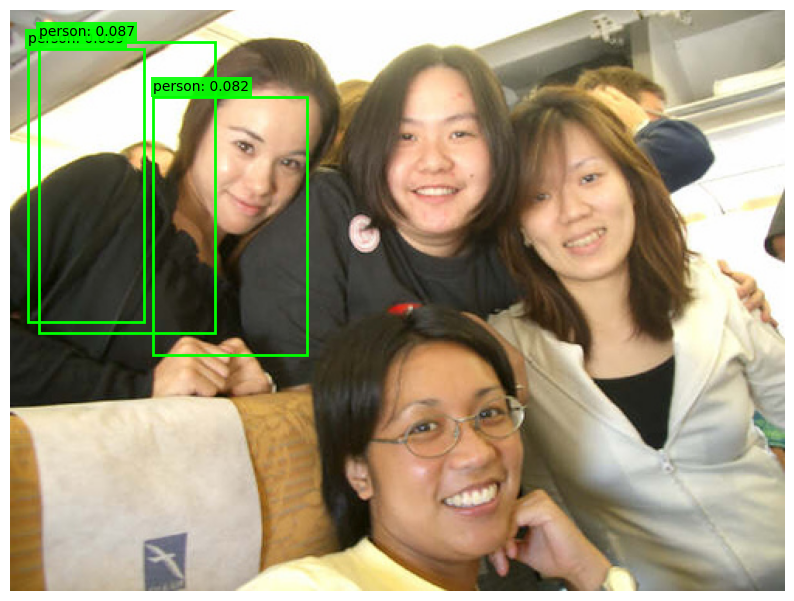

In [19]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
img = cv2.imread('./data/VOCdevkit/VOC2012/JPEGImages/2008_000277.jpg')
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
x = cv2.resize(rgb_img, (224,224)).astype(np.float32)/255.0
x = torch.from_numpy(x.transpose(2,0,1))[None].to(device)
py = l_m(x)
print(py.shape)

f, ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(rgb_img)
ax.axis('off')
out_data = decode_yolo_output(py, score_thr=0.08, iou_thr=0.08, max_box=20, topk=5, oj_img_size=(224,224))
if type(out_data) == list:
    dets = out_data
else:
    dets = out_data[0]
for (xa,ya,xb,yb,sc,ci) in dets:
    xa,ya,xb,yb = map(int, [xa,ya,xb,yb]) # 1회성 동작하므로 메모리 관리 측면에서 효율적임
    ax.add_patch(Rectangle((xa,ya), xb-xa, yb-ya, fill=False, edgecolor='lime', linewidth=2))
    ax.text(xa,max(0, ya-4), f'{classes[ci]}: {sc:.3f}', fontsize=10, color='black', 
            bbox=dict(facecolor='lime', alpha=0.9, edgecolor='none', pad=2))
plt.show()

In [ ]:
# import cv2
# img_path='./data/VOCdevkit/VOC2012/JPEGImages/2008_000277.jpg'

# img=cv2.imread(img_path)
# rgb_img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
# x=cv2.resize(rgb_img,(224,224)).astype(np.float32)/255.0
# x=torch.from_numpy(x.transpose(2,0,1))[None].to(device)
# # py=m(x)
# py=l_m(x)
# import matplotlib.pyplot as plt
# from matplotlib.patches import Rectangle
# f,ax=plt.subplots(1,1,figsize=(10,10))
# ax.imshow(rgb_img)
# ax.axis('off')
# out_data=decode_yolo_output(py,score_thr=0.08,iou_thr=0.08,max_box=20,topk=5,oj_img_size=(224,224))
# if type(out_data)==list:
#     dets=out_data
# else:
#     dets=out_data[0]
# for (xa,ya,xb,yb,sc,ci) in  dets:
#     #xa,ya,xb,yb=int(xa),int(ya),int(xb),int(yb)
#     xa,ya,xb,yb=map(int,[xa,ya,xb,yb])#1회성 동작
#     ax.add_patch(Rectangle((xa,ya),xb-xa,yb-ya,fill=False,edgecolor='lime',linewidth=2))
#     ax.text(xa,max(0,ya-4),f'{classes[ci]}:{sc:.3f}',fontsize=10,color='black'
#             ,bbox=dict(facecolor='lime',alpha=0.9,edgecolor='none',pad=2))
# plt.show()


In [ ]:
# 8. 예측
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
w = torch.load('weights/'+SAVE_PATH, device)